<a href="https://colab.research.google.com/github/KuChoiLab/2026_bomun_workshop/blob/main/Proteomics_practice/Mass%20Spectrometry/MS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Download tools to use R in a Python runtime.
(As shown in the bottom right, the current environment is python3.)

In [ ]:
!pip install -q rpy2
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


Download and extract the R library packages.

In [ ]:
!pip install -q gdown

import gdown

gdown.download(
    id="1X4n6zG2yF5W5nCObGyJHAGJ4_LM_ICBQ",
    output="MS_library_packages.tar",
    quiet=False
)

!tar -xf MS_library_packages.tar -C /content/

Downloading...
From (original): https://drive.google.com/uc?id=1X4n6zG2yF5W5nCObGyJHAGJ4_LM_ICBQ
From (redirected): https://drive.google.com/uc?id=1X4n6zG2yF5W5nCObGyJHAGJ4_LM_ICBQ&confirm=t&uuid=7bc65c83-3a07-49d8-92ea-729b7db75d1d
To: /content/MS_library_packages.tar
100%|██████████| 861M/861M [00:08<00:00, 107MB/s]


Set the R package library path and load the packages.

In [ ]:
%%R

lib <- "/content/content/drive/MyDrive/MOFA_test/R_libs"
.libPaths(c(lib, .libPaths()))

pkgs <- c(
"data.table","ggplot2","limma","dplyr","ggrepel",
"pheatmap","msigdbr","clusterProfiler","org.Hs.eg.db"
)

for(p in pkgs){
  suppressPackageStartupMessages(library(p, character.only=TRUE))
}

cat("loaded")

loaded


Download the raw intensity matrix, which is the output of MaxQuant.

In [ ]:
!pip install -q gdown

import gdown

file_id = "12HK-vd6rnNSt1_a_oZdHKd9vazJwi2QA"
output = "MS_raw_intensity_matrix.txt"

gdown.download(id=file_id, output=output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=12HK-vd6rnNSt1_a_oZdHKd9vazJwi2QA
To: /content/MS_raw_intensity_matrix.txt
100%|██████████| 3.10M/3.10M [00:00<00:00, 22.5MB/s]


'MS_raw_intensity_matrix.txt'

Load the raw intensity matrix and check the file structure.

(Each row represents one protein group, and each column consists of protein identification information or sample-wise quantitative values.

The Protein IDs column at the front indicates the list of UniProt IDs of proteins included in that protein group. Since multiple proteins can be mapped to a single protein group, multiple IDs separated by semicolons may be included.

The Gene names column provides the gene names corresponding to the protein group, and similarly, when multiple genes are mapped, they are displayed separated by semicolons. This reflects protein inference ambiguity.)

In [ ]:
%%R
pg <- fread(
  "MS_raw_intensity_matrix.txt",
  sep = "\t",
  fill = TRUE,
  quote = "",
  data.table = FALSE
)

id_cols <- c("Protein IDs","Gene names")
int_cols <- grep("^Intensity ", colnames(pg), value = TRUE)
pg[1:5, c(id_cols, int_cols[1:20])]

                                                                         Protein IDs
1                                                                         A0A075B6J9
2                                                                  A0A075B6K5;P80748
3 P01615;A0A075B6P5;P01614;A0A087WW87;P06310;A2NJV5;A0A0A0MRZ7;A0A075B6S6;A0A075B6S2
4                                                              A0A0C4DH68;A0A075B6R9
5                                                   A0A0C4DH67;A0A0C4DH69;A0A075B6S5
                                                                             Gene names
1                                                                              IGLV2-18
2                                                                      IGLV3-9;IGLV3-21
3 IGKV2D-28;IGKV2-28;IGKV2D-40;IGKV2-40;IGKV2-30;IGKV2-29;IGKV2D-26;IGKV2D-30;IGKV2D-29
4                                                                    IGKV2-24;IGKV2D-24
5                                                 

Performs filtering by removing protein groups flagged as Reverse, Potential contaminant, or Only identified by site.

(Reverse entries are decoy matches used for FDR estimation, Potential contaminants are common laboratory contaminants, and Only identified by site indicates low-confidence protein identification based solely on modification site evidence, not on peptide evidence.)

In [ ]:
%%R
n_total <- nrow(pg)

n_reverse <- sum(pg$Reverse == "+", na.rm = TRUE)
n_contam  <- sum(pg$`Potential contaminant` == "+", na.rm = TRUE)
n_site    <- sum(pg$`Only identified by site` == "+", na.rm = TRUE)

pg_f <- pg[pg$Reverse != "+" &
             pg$`Potential contaminant` != "+" &
             pg$`Only identified by site` != "+", ]

n_final <- nrow(pg_f)

data.frame(
  total = n_total,
  removed_reverse = n_reverse,
  removed_contaminant = n_contam,
  removed_site_only = n_site,
  final = n_final
)

  total removed_reverse removed_contaminant removed_site_only final
1   160               1                  14                 1   144


Construct protein quantification table with identifiers and check the data structure.

In [ ]:
%%R
lfq_cols <- grep("^LFQ intensity", colnames(pg), value = TRUE)
lfq <- pg[, lfq_cols]
lfq[lfq == 0] <- NA
lfq <- as.data.frame(lapply(lfq, as.numeric))

id_cols <- c("Protein IDs","Gene names")
int_cols <- grep("^Intensity ", colnames(pg), value = TRUE)

view_df <- pg[, c(id_cols, int_cols)]

head(view_df, 5)

                                                                         Protein IDs
1                                                                         A0A075B6J9
2                                                                  A0A075B6K5;P80748
3 P01615;A0A075B6P5;P01614;A0A087WW87;P06310;A2NJV5;A0A0A0MRZ7;A0A075B6S6;A0A075B6S2
4                                                              A0A0C4DH68;A0A075B6R9
5                                                   A0A0C4DH67;A0A0C4DH69;A0A075B6S5
                                                                             Gene names
1                                                                              IGLV2-18
2                                                                      IGLV3-9;IGLV3-21
3 IGKV2D-28;IGKV2-28;IGKV2D-40;IGKV2-40;IGKV2-30;IGKV2-29;IGKV2D-26;IGKV2D-30;IGKV2D-29
4                                                                    IGKV2-24;IGKV2D-24
5                                                 

Retains proteins detected in at least 10% of samples within each groups based on non-missing intensity values.

In [ ]:
%%R
obs <- !is.na(lfq)
normal_cols  <- grep("normal", colnames(lfq), ignore.case = TRUE, value = TRUE)
obesity_cols <- grep("obesity", colnames(lfq), ignore.case = TRUE, value = TRUE)

keep <- (rowMeans(obs[, normal_cols]) >= 0.10) &
  (rowMeans(obs[, obesity_cols]) >= 0.10)

pg <- pg[keep, ]
lfq <- lfq[keep, ]

Applies log2 transformation (log2(x+1)) to intensities to stabilize variance.

In [ ]:
%%R
lfq_log2 <- log2(lfq + 1)

Cleans column names by removing prefixes and derives sample metadata including group (Normal vs Obesity) and sex (Male vs Female).

In [ ]:
%%R
sample_names <- colnames(lfq_log2)
sample_names <- sub("^LFQ[._ ]intensity[._ ]", "", sample_names, ignore.case = TRUE)
sample_names <- gsub("\\.", "_", sample_names)
colnames(lfq_log2) <- sample_names

group <- factor(ifelse(grepl("normal", sample_names, ignore.case = TRUE),
                       "Normal","Obesity"))

idx <- as.integer(sub(".*?(\\d+)$", "\\1", sample_names))
sex <- factor(ifelse(idx <= 5, "Male","Female"),
              levels = c("Male","Female"))

Missing values were median-imputed only for PCA visualization. Because DDA-LFQ missingness reflects a hybrid of MAR and MNAR, downstream statistical analyses were performed using NA values without imputation to avoid bias and inflated false positives. (limma allows analysis with missing values.)

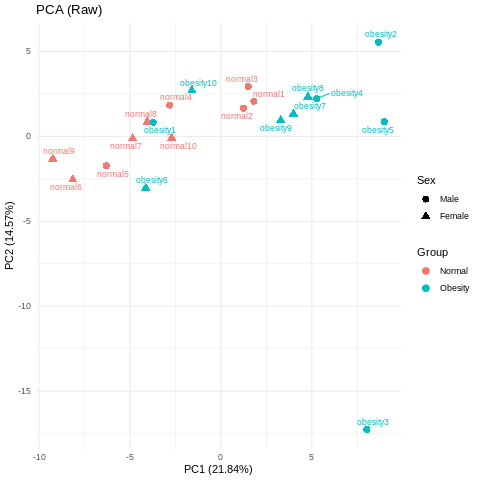

In [ ]:
%%R
lfq_pca <- lfq_log2
for (i in seq_len(ncol(lfq_pca))) {
  med <- median(lfq_pca[, i], na.rm = TRUE)
  lfq_pca[is.na(lfq_pca[, i]), i] <- med
}

pca_raw <- prcomp(t(lfq_pca), scale. = TRUE)

pve_raw <- (pca_raw$sdev^2) / sum(pca_raw$sdev^2)
pc1_lab_raw <- paste0("PC1 (", round(100 * pve_raw[1], 2), "%)")
pc2_lab_raw <- paste0("PC2 (", round(100 * pve_raw[2], 2), "%)")

pca_df_raw <- data.frame(
  Sample = sample_names,
  PC1 = -pca_raw$x[,1],
  PC2 = pca_raw$x[,2],
  Group = group,
  Sex = sex
)

ggplot(pca_df_raw, aes(PC1, PC2, color = Group, shape = Sex)) +
  geom_point(size = 3) +
  geom_text_repel(aes(label = Sample),
                  size = 3,
                  show.legend = FALSE) +
  labs(x = pc1_lab_raw,
       y = pc2_lab_raw,
       title = "PCA (Raw)") +
  theme_minimal()

Batch effects associated with sex were removed while preserving group effects. Compared to the raw PCA, group separation improved after correction, and the batch-corrected data were used for downstream analyses.

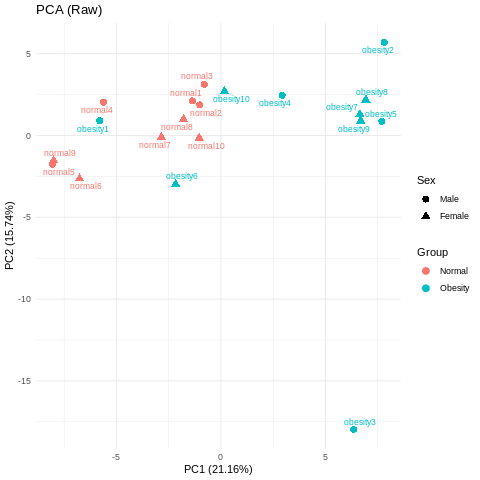

In [ ]:
%%R
lfq_adj <- removeBatchEffect(as.matrix(lfq_log2),
                             batch = sex,
                             design = model.matrix(~ group))

lfq_adj_pca <- lfq_adj
for (i in seq_len(ncol(lfq_adj_pca))) {
  med <- median(lfq_adj_pca[, i], na.rm = TRUE)
  lfq_adj_pca[is.na(lfq_adj_pca[, i]), i] <- med
}

pca_adj <- prcomp(t(lfq_adj_pca), scale. = TRUE)

pve_adj <- (pca_adj$sdev^2) / sum(pca_adj$sdev^2)
pc1_lab_adj <- paste0("PC1 (", round(100 * pve_adj[1], 2), "%)")
pc2_lab_adj <- paste0("PC2 (", round(100 * pve_adj[2], 2), "%)")

pca_df_adj <- data.frame(
  Sample = sample_names,
  PC1 = pca_adj$x[,1],
  PC2 = pca_adj$x[,2],
  Group = group,
  Sex = sex
)

ggplot(pca_df_adj, aes(PC1, PC2, color = Group, shape = Sex)) +
  geom_point(size = 3) +
  geom_text_repel(aes(label = Sample),
                  size = 3,
                  show.legend = FALSE) +
  labs(x = pc1_lab_adj,
       y = pc2_lab_adj,
       title = "PCA (Raw)") +
  theme_minimal()

This table was generated from protein quantification (log2 intensities) using a limma linear model including group (Normal vs Obesity) and sex. It contains protein identifiers, sample-level intensities, and limma statistical outputs describing differential protein abundance.

In [ ]:
%%R
design <- model.matrix(~ group + sex)

fit <- lmFit(lfq_log2, design)
fit <- eBayes(fit)

coef_name <- grep("^group", colnames(design), value = TRUE)[1]

res <- topTable(
  fit,
  coef = coef_name,
  number = Inf,
  adjust.method = "BH",
  sort.by = "none"
)

anno <- pg[rownames(res), c("Protein IDs","Gene names")]
result <- cbind(anno, lfq_log2[rownames(res), ], res)

head(result)

                                                                         Protein IDs
1                                                                         A0A075B6J9
2                                                                  A0A075B6K5;P80748
3 P01615;A0A075B6P5;P01614;A0A087WW87;P06310;A2NJV5;A0A0A0MRZ7;A0A075B6S6;A0A075B6S2
4                                                              A0A0C4DH68;A0A075B6R9
5                                                   A0A0C4DH67;A0A0C4DH69;A0A075B6S5
6                                                                         A0A087WSY6
                                                                             Gene names
1                                                                              IGLV2-18
2                                                                      IGLV3-9;IGLV3-21
3 IGKV2D-28;IGKV2-28;IGKV2D-40;IGKV2-40;IGKV2-30;IGKV2-29;IGKV2D-26;IGKV2D-30;IGKV2D-29
4                                                    

A representative gene label (Gene_short) is created by taking the first gene name, or using Protein IDs when gene names are missing.

In [ ]:
%%R
result$Gene_short <- ifelse(
  is.na(result$`Gene names`) | result$`Gene names` == "",
  result$`Protein IDs`,
  sub(";.*", "", result$`Gene names`)
)

An FDR threshold (0.1) is defined, and adjusted p-values are transformed to −log10 scale to create a visualization metric

In [ ]:
%%R
FDR <- 0.1
result$neglog10FDR <- -log10(result$adj.P.Val)

Average expression (A) is combined with logFC to create an MA plot, significant proteins are defined by FDR, and significant proteins are labeled using representative gene names.

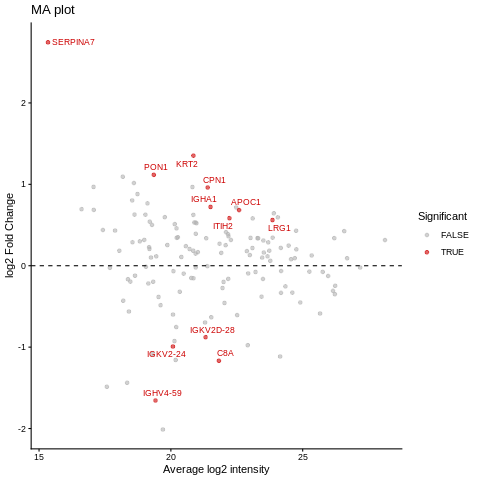

In [ ]:
%%R
avg_expr <- rowMeans(lfq_log2, na.rm = TRUE)

ma_df <- result
ma_df$A <- avg_expr
ma_df$Significant <- ma_df$adj.P.Val < FDR

ggplot(ma_df, aes(A, logFC, color = Significant)) +
  geom_point(alpha = 0.6, size = 1.5) +
  geom_text_repel(
    data = ma_df[ma_df$adj.P.Val < FDR, ],
    aes(A, logFC, label = Gene_short),
    size = 3,
    max.overlaps = Inf,
    show.legend = FALSE
  ) +
  scale_color_manual(values = c("grey70","red3")) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  theme_classic() +
  labs(
    title = "MA plot",
    x = "Average log2 intensity",
    y = "log2 Fold Change"
  )

A volcano plot is generated using logFC and −log10 FDR, significant proteins are defined by the FDR threshold, labeled with gene names, and the FDR cutoff is shown as a reference line.

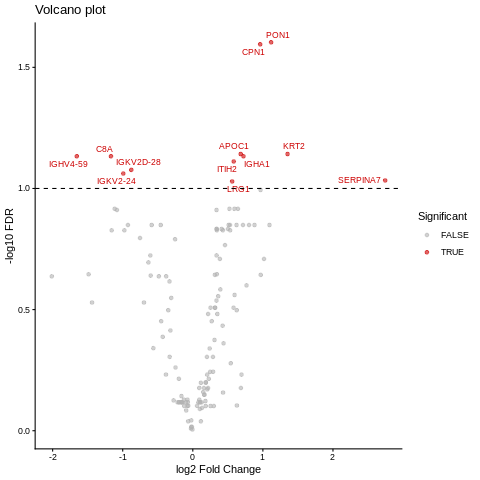

In [ ]:
%%R
vol_df <- result
vol_df$Significant <- vol_df$adj.P.Val < FDR

ggplot(vol_df, aes(logFC, neglog10FDR, color = Significant)) +
  geom_point(alpha = 0.6, size = 1.5) +
  geom_text_repel(
    data = vol_df[vol_df$adj.P.Val < FDR, ],
    aes(logFC, neglog10FDR, label = Gene_short),
    size = 3,
    max.overlaps = Inf,
    show.legend = FALSE
  ) +
  scale_color_manual(values = c("grey70","red3")) +
  geom_hline(yintercept = -log10(FDR), linetype = "dashed") +
  theme_classic() +
  labs(
    title = "Volcano plot",
    x = "log2 Fold Change",
    y = "-log10 FDR"
  )

Significant proteins (FDR threshold) are separated by logFC direction into upregulated and downregulated lists using representative gene names.

In [ ]:
%%R
deg <- result[result$adj.P.Val < FDR, ]

up_list   <- deg$Gene_short[deg$logFC > 0]
down_list <- deg$Gene_short[deg$logFC < 0]

deg_lists <- list(
  Upregulated = up_list,
  Downregulated = down_list
)

deg_lists

$Upregulated
[1] "KRT2"     "IGHA1"    "APOC1"    "LRG1"     "SERPINA7" "CPN1"     "ITIH2"   
[8] "PON1"    

$Downregulated
[1] "IGKV2D-28" "IGKV2-24"  "IGHV4-59"  "C8A"      



Protein-level differential results are summarized at the gene level, followed by conversion of gene symbols to Entrez IDs for downstream functional analysis.

In [ ]:
%%R
gene_df <- result %>%
  dplyr::select(Gene_short, t, adj.P.Val) %>%
  filter(!is.na(Gene_short), !is.na(t)) %>%
  group_by(Gene_short) %>%
  summarise(t = mean(t), adj.P.Val = min(adj.P.Val), .groups = "drop")

gene_df <- result %>%
  dplyr::select(Gene_short, t) %>%
  filter(!is.na(Gene_short), !is.na(t)) %>%
  group_by(Gene_short) %>%
  summarise(t = mean(t), .groups = "drop")

entrez <- bitr(
  gene_df$Gene_short,
  fromType = "SYMBOL",
  toType = "ENTREZID",
  OrgDb = org.Hs.eg.db
)

gene_df <- inner_join(gene_df, entrez, by = c("Gene_short" = "SYMBOL"))

'select()' returned 1:1 mapping between keys and columns
In addition: Warning message:
In bitr(gene_df$Gene_short, fromType = "SYMBOL", toType = "ENTREZID",  :
  0.71% of input gene IDs are fail to map...


A ranked gene list is used to perform GO Biological Process GSEA, enrichment results are organized, core enriched genes are converted to gene symbols for interpretation, and key enriched pathways are visualized.

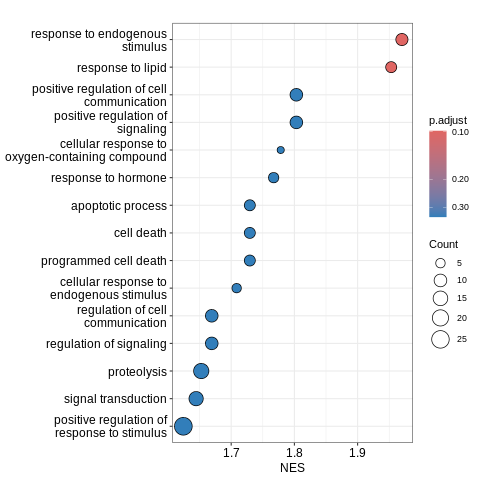

In [ ]:
%%R
geneList <- gene_df$t
names(geneList) <- gene_df$ENTREZID
geneList <- sort(geneList, decreasing = TRUE)

gsea_bp <- gseGO(
  geneList = geneList,
  OrgDb = org.Hs.eg.db,
  ont = "BP",
  keyType = "ENTREZID",
  minGSSize = 5,
  maxGSSize = 500,
  pvalueCutoff = 0.4,
  verbose = FALSE
)

gsea_bp_res <- as.data.frame(gsea_bp)

core_list <- strsplit(gsea_bp_res$core_enrichment, "/")

core_symbol <- lapply(core_list, function(x){
  id <- suppressWarnings(
    suppressMessages(
      bitr(
        x,
        fromType = "ENTREZID",
        toType = "SYMBOL",
        OrgDb = org.Hs.eg.db
      )
    )
  )
  paste(unique(id$SYMBOL), collapse = "/")
})

gsea_bp_res$core_enrichment_SYMBOL <- unlist(core_symbol)

write.csv(gsea_bp_res, "GSEA_BP_results.csv", row.names = FALSE)

dotplot(
  gsea_bp,
  showCategory = 15,
  x = "NES"
)